# Financial Engineering with Python: LBO Modeling from Entry to Exit

It is Monday morning. A private equity fund has received a potential buyout opportunity, and the investment committee does not want a spreadsheet dump. It wants a clear answer: if the fund acquires this company under these terms, can it generate an acceptable sponsor return without relying on unrealistic assumptions?

This notebook keeps the original analytical engine intact and reframes it as the working document of the associate or VP preparing that recommendation. The point is not to learn Python syntax. The point is to make the underwriting logic transparent, auditable, and easy to challenge.

**Decision flow**
- What are we being asked to underwrite?
- What price are we really paying?
- How do we actually close the transaction?
- What must the business deliver after closing?
- Is deleveraging happening fast enough?
- Would lenders still be comfortable with this deal?
- How does the sponsor get paid?
- What can break the deal?
- How could this model later be exposed through a simple analytical application?
        


## B. Monday morning case briefing

The situation is straightforward: a sponsor is considering a control acquisition and needs a recommendation before the investment committee meeting. The committee is not deciding whether LBO math exists. It is deciding whether this specific deal deserves capital.

> Core underwriting question: if we buy this company with the proposed leverage package, and the business performs in line with the case assumptions, do we earn a return that is good enough without depending on aggressive multiple expansion or fragile operating forecasts?

**Who is asking what?**
- **Sponsor:** How much equity has to go in, and what can reasonably come out at exit?
- **Lenders:** Will the company convert earnings into cash fast enough to protect the debt stack?
- **Investment committee:** Is the return case supported by business performance and deleveraging, or only by optimism?

**Useful terms for the discussion**
- **LBO**: an acquisition funded with a mix of debt and sponsor equity.
- **EBITDA**: a proxy for operating earnings before financing and non-cash depreciation.
- **Enterprise Value**: the value of the business operations, independent of capital structure.
- **Sources & Uses**: the schedule that shows where acquisition funding comes from and where it goes.
- **Deleveraging**: the reduction of debt over time through cash generation.
- **IRR**: the annualized return earned by the sponsor.
- **MOIC**: the cash multiple earned on sponsor equity.

The rest of the notebook follows the same sequence an associate would use to prepare the committee pack: define the underwriting perimeter, test the price, fund the transaction, project the business, monitor the debt, and then judge whether the sponsor gets paid for the risk taken.
        


### Code setup

The notebook uses a small shared LBO engine so that the notebook and the Streamlit demo stay fully aligned. The helper module keeps the calculations reusable; this notebook remains the investment-case walkthrough and the teaching asset.
        


In [1]:
# Standard imports for the notebook environment and charting.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

try:
    from IPython.display import Markdown, display
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

# This makes the notebook work whether it is launched from the repo root or from the notebooks folder.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.gemini_reporting import generate_investment_commentary
from utils.lbo_engine import run_lbo_model

# Keep tables readable for classroom discussion.
pd.options.display.float_format = "{:,.2f}".format
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "navy": "#14324A",
    "teal": "#1F6F78",
    "sand": "#D7C3A3",
    "slate": "#5A6C7D",
    "green": "#2D7D46",
    "red": "#A6473C",
}


def eur_millions(value, _position=None):
    # Most outputs in the model are in EUR millions, so the same formatter is reused across charts.
    return f"EUR {value:,.0f}m"


def style_axes(axis):
    # A cleaner frame makes the finance story easier to read from the chart.
    axis.spines[["top", "right"]].set_visible(False)


def add_bar_labels(axis, bars, offset=10, fmt="{:.1f}"):
    # Bar labels help students reconcile the visual with the exact values.
    for bar in bars:
        height = bar.get_height()
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=9,
            color=COLORS["navy"],
        )


def format_inputs_table(table):
    # Convert raw numbers into the units students expect when reading a deal sheet.
    formatted = table.copy()
    formatted["Display Value"] = formatted.apply(
        lambda row: (
            f"{row['Value'] * 100:.1f}%" if row["Unit"] == "%"
            else f"{row['Value']:.1f}x" if row["Unit"] == "x"
            else f"EUR {row['Value']:.2f}" if row["Unit"] == "EUR/share"
            else f"{row['Value']:.1f}m" if row["Unit"] == "m shares"
            else f"EUR {row['Value']:,.1f}m" if row["Unit"] == "EURm"
            else f"{int(row['Value'])}" if row["Unit"] == "year"
            else f"{row['Value']}"
        ),
        axis=1,
    )
    return formatted[["Group", "Assumption", "Display Value"]]


def format_metric_table(table):
    # Some metrics are percentages, some are multiples, and some are money values.
    formatted = table.copy()
    formatted["Display Value"] = formatted.apply(
        lambda row: (
            f"{row['Value'] * 100:.1f}%" if row["Metric"] in {"Takeover premium", "IRR"}
            else f"{row['Value']:.2f}x" if row["Metric"] == "MOIC"
            else f"EUR {row['Value']:,.2f}" if row["Metric"] == "Implied offer price per share"
            else f"EUR {row['Value']:,.1f}m"
        ),
        axis=1,
    )
    return formatted[["Metric", "Display Value"]]


def plot_heatmap(table, title, ax, percent_values=False):
    # Heatmaps are useful in class because they reveal the full return pattern at a glance.
    values = table.to_numpy(dtype=float)
    image = ax.imshow(values, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_title(title)
    ax.set_xlabel(table.columns.name)
    ax.set_ylabel(table.index.name)

    midpoint = values.mean()
    for row_idx, row_value in enumerate(table.index):
        for col_idx, col_value in enumerate(table.columns):
            display_value = table.loc[row_value, col_value]
            label = f"{display_value * 100:.1f}%" if percent_values else f"{display_value:.2f}x"
            ax.text(
                col_idx,
                row_idx,
                label,
                ha="center",
                va="center",
                fontsize=9,
                color="white" if display_value > midpoint else COLORS["navy"],
            )

    plt.colorbar(image, ax=ax, shrink=0.82)


# Run the base-case LBO once and keep every intermediate table available for the walkthrough.
results = run_lbo_model()
inputs_table = results["inputs_table"]
entry_valuation = results["entry_valuation"]
sources_and_uses = results["sources_and_uses"]
operating_projection = results["operating_projection"]
debt_schedule = results["debt_schedule"]
credit_metrics = results["credit_metrics"]
returns_summary = results["returns_summary"]
value_creation_bridge = results["value_creation_bridge"]
sensitivities = results["sensitivities"]

returns_lookup = returns_summary.set_index("Metric")["Value"]
entry_lookup = entry_valuation.set_index("Metric")["Value"]
        


## C. 1. What are we being asked to underwrite?

Before the committee debates return, it needs a clean statement of the case. This section defines the perimeter of the opportunity: purchase assumptions, financing mix, operating starting point, taxes, fees, and exit assumptions.

**Why this matters economically:** LBO outputs are only as credible as the assumptions underneath them. Hidden assumptions create false precision.

**Question in the room:** What exactly is management expected to deliver, and what parts of the deal structure are fixed versus negotiable?

**Where this sits in the process:** This is the underwriting sheet the sponsor team would circulate before any deeper committee debate.

For alignment with the classroom Excel file, the historical data and the first three projected operating years match the class case. The later sensitivity work stresses that same base case rather than introducing a different forecasting architecture.

> **IC takeaway:** This table is the deal's control panel. If the final answer looks too good or too weak, the committee should trace the result back here first.

With the perimeter defined, the next question is whether the price leaves enough room for the sponsor to make money.
        


In [2]:
# Show the base-case assumptions in the same grouped logic used in class.
display(format_inputs_table(inputs_table))
        


,Group,Assumption,Display Value
0,Deal inputs,Share price,EUR 2.50
1,Deal inputs,Diluted shares,369.0m
2,Deal inputs,Net debt,EUR 135.2m
3,Valuation assumptions,Entry multiple,7.0x
4,Financing assumptions,Senior debt,35.0%
5,Financing assumptions,Subordinated debt,35.0%
6,Financing assumptions,Sponsor equity,30.0%
7,Financing assumptions,Senior interest rate,6.0%
8,Financing assumptions,Subordinated interest rate,6.5%
9,Operating starting point,EBIT,EUR 163.9m


## D. 2. What price are we really paying?

The committee never approves a deal at a headline multiple alone. It wants to know what that multiple implies for enterprise value, equity value, offer price per share, and takeover premium.

**Why this matters economically:** Entry price is one of the most powerful drivers of sponsor returns. A good company can still be a bad LBO if the fund overpays.

**Question in the room:** Is the sponsor paying a control price that can still be justified by the expected cash generation and exit economics?

**Where this sits in the process:** This is the first checkpoint where the IC tests whether the seller's ask is compatible with disciplined underwriting.

In the base case, the 7.0x entry multiple translates into a meaningful premium to the unaffected share price, which is realistic for a control transaction and therefore worth underwriting rather than dismissing as purely theoretical.

> **IC takeaway:** The price is high enough to matter. From here onward, the burden of proof shifts to the operating case and the financing structure.

Once price is set, the next question is practical: how does the fund actually get the deal closed?
        


,Metric,Display Value
0,Historical EBITDA,EUR 240.8m
1,Entry Enterprise Value,"EUR 1,685.6m"
2,Less: Net debt,EUR -135.2m
3,Implied Equity Value,"EUR 1,550.4m"
4,Implied offer price per share,EUR 4.20
5,Takeover premium,68.1%


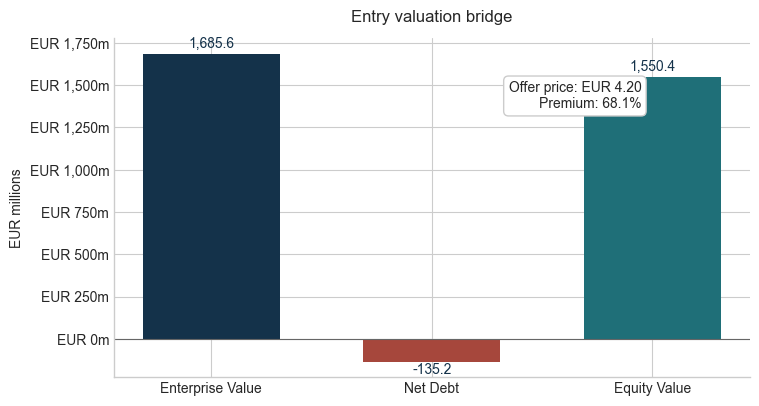

In [3]:
# Start with the valuation outputs before moving to the chart.
display(format_metric_table(entry_valuation))

# The bridge keeps the logic explicit: Enterprise Value minus net debt equals equity value.
bridge = pd.DataFrame(
    {
        "Label": ["Enterprise Value", "Net Debt", "Equity Value"],
        "Value": [
            entry_lookup["Entry Enterprise Value"],
            entry_lookup["Less: Net debt"],
            entry_lookup["Implied Equity Value"],
        ],
        "Color": [COLORS["navy"], COLORS["red"], COLORS["teal"]],
    }
)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
# Plot the bridge as three bars so students can see the transition from firm value to shareholder value.
bars = ax.bar(bridge["Label"], bridge["Value"], color=bridge["Color"], width=0.62)
for idx, row in bridge.iterrows():
    y = row["Value"] + 35 if row["Value"] >= 0 else row["Value"] - 70
    ax.text(idx, y, f"{row['Value']:,.1f}", ha="center", color=COLORS["navy"], fontsize=10)
ax.set_title("Entry valuation bridge", pad=12)
ax.set_ylabel("EUR millions")
ax.yaxis.set_major_formatter(FuncFormatter(eur_millions))
ax.axhline(0, color="#666666", linewidth=0.8)
ax.text(
    1.95,
    entry_lookup["Implied Equity Value"] * 0.88,
    f"Offer price: EUR {entry_lookup['Implied offer price per share']:.2f}\nPremium: {entry_lookup['Takeover premium'] * 100:.1f}%",
    ha="right",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc"},
)
style_axes(ax)
plt.show()
        


## E. 3. How do we actually close the transaction?

A signed purchase price is not a closed deal. The sponsor still has to fund every use of cash and prove that the capital structure is credible on day one.

**Why this matters economically:** Sources & Uses converts valuation into the real equity check and the actual debt burden the business must carry after closing.

**Question in the room:** How much money is needed, where does it come from, and how much sponsor equity must be written before lenders will support the deal?

**Where this sits in the process:** This is the transaction mechanics page that links the purchase price to the post-close capital structure.

The class case keeps the stack deliberately simple: senior debt, subordinated debt, and the residual sponsor equity contribution needed to bridge the gap.

> **IC takeaway:** This section turns valuation into a financing commitment. It shows exactly how much leverage the business has to service and how much equity the sponsor truly has at risk.

With the deal closed on paper, the central underwriting question becomes operational: what does the company have to deliver after closing?
        


,Uses,Sources
Acquisition of equity,"1,550.40",
Refinanced debt,135.20,
Fees,8.43,
Total Uses,"1,694.03",
Senior debt,,592.91
Subordinated debt,,592.91
Sponsor equity,,508.21
Total Sources,,"1,694.03"


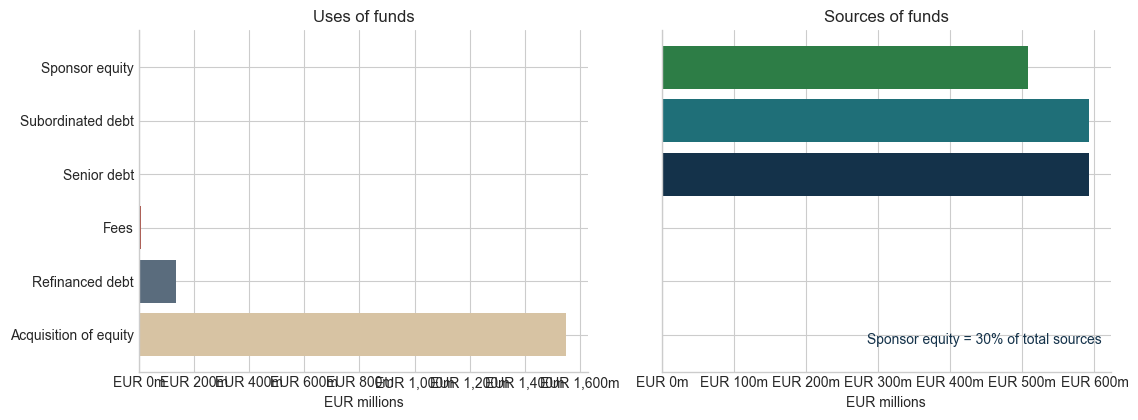

In [4]:
# Show the exact transaction funding schedule first.
display(sources_and_uses.fillna(""))

# Split the table into uses and sources so both sides can be compared visually.
uses = sources_and_uses["Uses"].dropna().drop("Total Uses")
sources = sources_and_uses["Sources"].dropna().drop("Total Sources")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
axes[0].barh(uses.index, uses.values, color=[COLORS["sand"], COLORS["slate"], COLORS["red"]])
axes[0].set_title("Uses of funds")
axes[1].barh(sources.index, sources.values, color=[COLORS["navy"], COLORS["teal"], COLORS["green"]])
axes[1].set_title("Sources of funds")

for axis in axes:
    axis.set_xlabel("EUR millions")
    axis.xaxis.set_major_formatter(FuncFormatter(eur_millions))
    style_axes(axis)

axes[1].text(
    0.98,
    0.08,
    f"Sponsor equity = {sources['Sponsor equity'] / sources.sum():.0%} of total sources",
    transform=axes[1].transAxes,
    ha="right",
    color=COLORS["navy"],
)
plt.tight_layout()
plt.show()
        


## F. 4. What must the business deliver after closing?

After signing, the model stops being a capital markets exercise and becomes an operating one. The sponsor can only delever if the company converts its business plan into real cash after taxes and reinvestment.

**Why this matters economically:** EBITDA growth helps, but lenders are repaid with cash left over after interest, tax, working capital needs, and capital expenditure.

**Question in the room:** What level of operating delivery is required for the deal to work, and how much of reported earnings actually becomes debt-paying cash?

**Where this sits in the process:** This is the post-close operating case that management, the sponsor, and the IC will all monitor against the original underwriting memo.

The business grows EBITDA across the projection period, but not every euro of EBITDA becomes debt-repaying cash. That conversion gap is one of the most important realities in any LBO.

> **IC takeaway:** The deal is not supported by accounting profit alone. The sponsor needs durable cash conversion, not just a growth story.

If the operating case is believable, the next question is whether that cash actually reduces leverage fast enough.
        


,EBIT,D&A,OWC,Capex,EBITDA,Change in OWC,Interest expense,Tax expense,Cash flow available for debt repayment
Historical,163.90,76.90,-86.90,127.70,240.80,0.00,NaN,NaN,NaN
Year 1,177.29,81.90,-92.19,113.47,259.19,5.29,72.87,36.55,41.60
Year 2,186.16,84.71,-96.80,119.14,270.86,4.61,70.25,40.57,45.51
Year 3,195.46,87.77,-101.64,125.10,283.24,4.84,67.36,44.84,50.78


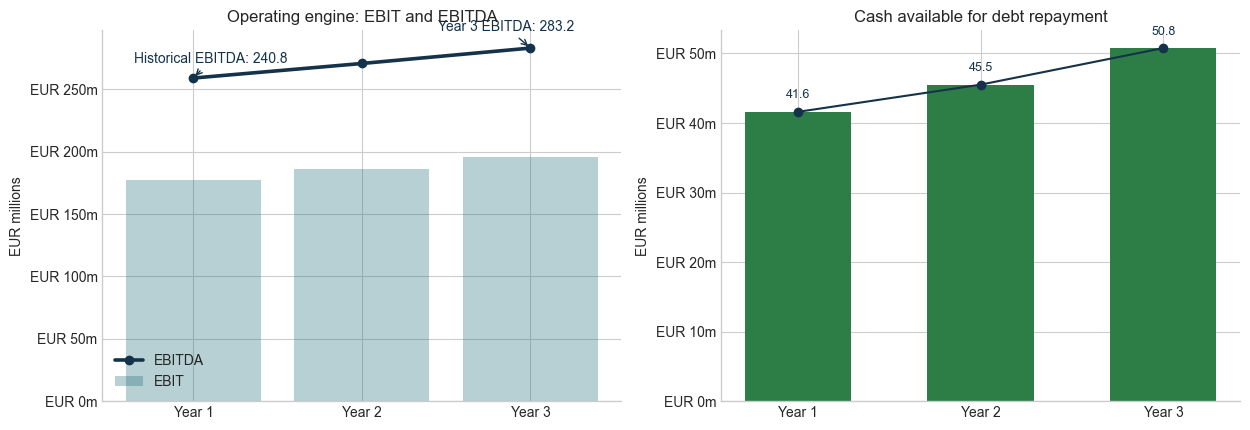

In [5]:
# Extend the operating table with interest, taxes, and debt-paying cash so the full operating engine is visible.
projection_view = operating_projection.copy()
projection_view["Interest expense"] = debt_schedule["Interest expense"]
projection_view["Tax expense"] = debt_schedule["Tax expense"]
projection_view["Cash flow available for debt repayment"] = debt_schedule["Cash flow available for debt repayment"]
display(projection_view)

# The charts focus on projected years because that is where the LBO economics play out.
projected = operating_projection.drop(index="Historical")
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

axes[0].plot(projected.index, projected["EBITDA"], marker="o", linewidth=2.6, color=COLORS["navy"], label="EBITDA")
axes[0].bar(projected.index, projected["EBIT"], color=COLORS["teal"], alpha=0.32, label="EBIT")
axes[0].set_title("Operating engine: EBIT and EBITDA")
axes[0].set_ylabel("EUR millions")
axes[0].yaxis.set_major_formatter(FuncFormatter(eur_millions))
axes[0].legend(frameon=False)
axes[0].annotate(
    f"Historical EBITDA: {operating_projection.loc['Historical', 'EBITDA']:.1f}",
    xy=(0, projected["EBITDA"].iloc[0]),
    xytext=(-0.35, projected["EBITDA"].iloc[0] + 12),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "color": COLORS["navy"]},
    color=COLORS["navy"],
)
axes[0].annotate(
    f"Year 3 EBITDA: {projected['EBITDA'].iloc[-1]:.1f}",
    xy=(2, projected["EBITDA"].iloc[-1]),
    xytext=(1.45, projected["EBITDA"].iloc[-1] + 14),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "color": COLORS["navy"]},
    color=COLORS["navy"],
)
style_axes(axes[0])

# This is the cash available for the sweep after interest, taxes, working capital, and capex.
cash_bars = axes[1].bar(debt_schedule.index, debt_schedule["Cash flow available for debt repayment"], color=COLORS["green"], width=0.58)
axes[1].plot(debt_schedule.index, debt_schedule["Cash flow available for debt repayment"], color=COLORS["navy"], marker="o", linewidth=1.5)
axes[1].set_title("Cash available for debt repayment")
axes[1].set_ylabel("EUR millions")
axes[1].yaxis.set_major_formatter(FuncFormatter(eur_millions))
add_bar_labels(axes[1], cash_bars, offset=1.5)
style_axes(axes[1])

plt.tight_layout()
plt.show()
        


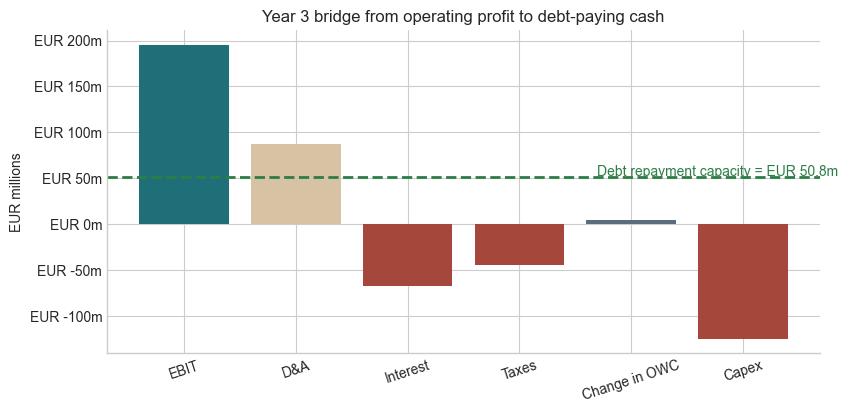

In [6]:
# Use the exit year to show one full bridge from accounting profit to debt-paying cash.
bridge_year = "Year 3"
# Positive items add to cash and negative items consume cash.
components = pd.Series(
    {
        "EBIT": operating_projection.loc[bridge_year, "EBIT"],
        "D&A": operating_projection.loc[bridge_year, "D&A"],
        "Interest": -debt_schedule.loc[bridge_year, "Interest expense"],
        "Taxes": -debt_schedule.loc[bridge_year, "Tax expense"],
        "Change in OWC": operating_projection.loc[bridge_year, "Change in OWC"],
        "Capex": -operating_projection.loc[bridge_year, "Capex"],
    }
)

fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(
    components.index,
    components.values,
    color=[COLORS["teal"], COLORS["sand"], COLORS["red"], COLORS["red"], COLORS["slate"], COLORS["red"]],
)
ax.axhline(debt_schedule.loc[bridge_year, "Cash flow available for debt repayment"], color=COLORS["green"], linestyle="--", linewidth=2)
ax.text(
    len(components) - 0.15,
    debt_schedule.loc[bridge_year, "Cash flow available for debt repayment"] + 2,
    f"Debt repayment capacity = EUR {debt_schedule.loc[bridge_year, 'Cash flow available for debt repayment']:.1f}m",
    ha="right",
    color=COLORS["green"],
)
ax.set_title("Year 3 bridge from operating profit to debt-paying cash")
ax.set_ylabel("EUR millions")
ax.yaxis.set_major_formatter(FuncFormatter(eur_millions))
style_axes(ax)
plt.xticks(rotation=18)
plt.show()
        


## G. 5. Is deleveraging happening fast enough?

Once debt-paying cash is known, the sponsor and lenders both want the same next answer: does leverage come down quickly enough to improve the risk profile before exit?

**Why this matters economically:** Deleveraging is the mechanism that transfers value from lenders back to the sponsor over time.

**Question in the room:** How much debt remains each year, how much interest is absorbed along the way, and does the sweep meaningfully de-risk the capital structure?

**Where this sits in the process:** This is the section of the model where the operating plan is translated into a year-by-year debt paydown path.

The class case keeps the repayment rule clean: senior debt is repaid first, and subordinated debt only starts to amortize once the senior balance has been exhausted.

> **IC takeaway:** Faster debt reduction does not just improve optics. It lowers refinancing risk, strengthens exit equity value, and makes the sponsor case more defensible.

Debt can be falling and still leave lenders uncomfortable, so the next section tests the credit profile through their lens.
        


,Beginning senior debt,Interest expense on senior debt,Repayment of senior debt,Ending senior debt,Beginning subordinated debt,Interest expense on subordinated debt,Repayment of subordinated debt,Ending subordinated debt,Ending cash balance
Year,,,,,,,,,
Year 1,592.91,34.33,41.60,551.31,592.91,38.54,0.00,592.91,0.00
Year 2,551.31,31.71,45.51,505.80,592.91,38.54,0.00,592.91,0.00
Year 3,505.80,28.82,50.78,455.01,592.91,38.54,0.00,592.91,0.00


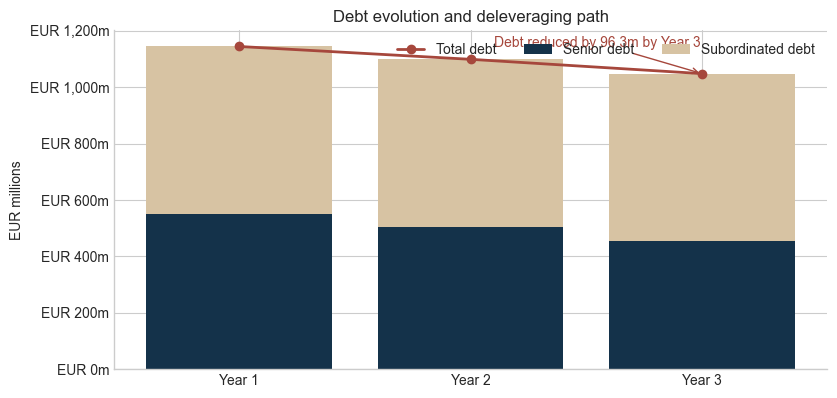

In [7]:
# Keep the debt schedule explicit so students can trace beginning balance, interest, repayment, and ending balance.
debt_view = debt_schedule[[
    "Beginning senior debt",
    "Interest expense on senior debt",
    "Repayment of senior debt",
    "Ending senior debt",
    "Beginning subordinated debt",
    "Interest expense on subordinated debt",
    "Repayment of subordinated debt",
    "Ending subordinated debt",
    "Ending cash balance",
]]
display(debt_view)

# Total debt is the stacked sum of senior and subordinated balances.
total_debt = debt_schedule["Ending senior debt"] + debt_schedule["Ending subordinated debt"]

fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(debt_schedule.index, debt_schedule["Ending senior debt"], color=COLORS["navy"], label="Senior debt")
ax.bar(
    debt_schedule.index,
    debt_schedule["Ending subordinated debt"],
    bottom=debt_schedule["Ending senior debt"],
    color=COLORS["sand"],
    label="Subordinated debt",
)
ax.plot(debt_schedule.index, total_debt, color=COLORS["red"], linewidth=2, marker="o", label="Total debt")
ax.set_title("Debt evolution and deleveraging path")
ax.set_ylabel("EUR millions")
ax.yaxis.set_major_formatter(FuncFormatter(eur_millions))
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.annotate(
    f"Debt reduced by {total_debt.iloc[0] - total_debt.iloc[-1]:.1f}m by Year 3",
    xy=(2, total_debt.iloc[-1]),
    xytext=(1.1, total_debt.iloc[-1] + 95),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "color": COLORS["red"]},
    color=COLORS["red"],
)
style_axes(ax)
plt.show()
        


## H. 6. Would lenders still be comfortable with this deal?

Absolute debt balances are not enough. Lenders judge the deal through leverage and coverage metrics that show whether the company is becoming safer or simply surviving.

**Why this matters economically:** Credit metrics determine whether the capital structure remains financeable and whether downside resilience is improving over time.

**Question in the room:** If performance lands as underwritten, do leverage and interest coverage move in a direction that a lender would still support?

**Where this sits in the process:** This is the lender-facing checkpoint that sits between the debt schedule and the sponsor's exit case.

In a healthy LBO, leverage falls while interest coverage rises. That is the pattern the committee wants to see before it gives credit to the modeled exit value.

> **IC takeaway:** A deal can show equity upside and still fail the lender test. Here, the capital structure becomes safer over time, which supports the credibility of the exit case.

If the business can support the debt, the remaining question is whether that operating and financing path creates an acceptable sponsor outcome.
        


,EBITDA / Interest expense,Total Debt / EBITDA,% of total debt repaid,% of senior debt repaid
Year,,,,
Year 1,3.56,4.41,3.5%,7.0%
Year 2,3.86,4.06,7.3%,8.3%
Year 3,4.20,3.70,11.6%,10.0%


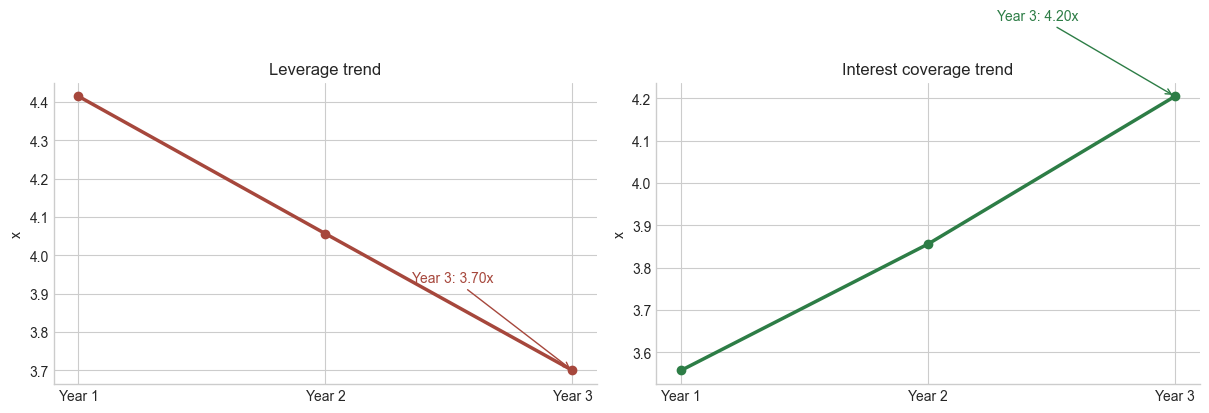

In [8]:
# Format the debt repayment ratios as percentages before showing the lender-facing metrics.
credit_view = credit_metrics.copy()
credit_view["% of total debt repaid"] = credit_view["% of total debt repaid"].map(lambda x: f"{x * 100:.1f}%")
credit_view["% of senior debt repaid"] = credit_view["% of senior debt repaid"].map(lambda x: f"{x * 100:.1f}%")
display(credit_view)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.3))
axes[0].plot(credit_metrics.index, credit_metrics["Total Debt / EBITDA"], marker="o", linewidth=2.5, color=COLORS["red"])
axes[0].set_title("Leverage trend")
axes[0].set_ylabel("x")
axes[0].annotate(
    f"Year 3: {credit_metrics['Total Debt / EBITDA'].iloc[-1]:.2f}x",
    xy=(2, credit_metrics["Total Debt / EBITDA"].iloc[-1]),
    xytext=(1.35, credit_metrics["Total Debt / EBITDA"].iloc[-1] + 0.23),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "color": COLORS["red"]},
    color=COLORS["red"],
)
style_axes(axes[0])

axes[1].plot(credit_metrics.index, credit_metrics["EBITDA / Interest expense"], marker="o", linewidth=2.5, color=COLORS["green"])
axes[1].set_title("Interest coverage trend")
axes[1].set_ylabel("x")
axes[1].annotate(
    f"Year 3: {credit_metrics['EBITDA / Interest expense'].iloc[-1]:.2f}x",
    xy=(2, credit_metrics["EBITDA / Interest expense"].iloc[-1]),
    xytext=(1.28, credit_metrics["EBITDA / Interest expense"].iloc[-1] + 0.18),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "color": COLORS["green"]},
    color=COLORS["green"],
)
style_axes(axes[1])

plt.tight_layout()
plt.show()
        


## I. 7. How does the sponsor get paid?

This is the section the investment committee ultimately cares about most. The model now brings together the operating trajectory, the remaining debt, and the exit valuation assumption to translate deal mechanics into sponsor economics.

**Why this matters economically:** The sponsor earns value only after lenders are repaid and the remaining enterprise value converts into exit equity.

**Question in the room:** Does the sponsor achieve an acceptable IRR and MOIC from realistic business performance, or only from a generous exit assumption?

**Where this sits in the process:** This is the returns page of the committee memo, where the recommendation usually becomes yes, no, or not yet.

In the classroom base case, returns are created without multiple expansion. That means the economics are driven mainly by operating improvement and deleveraging rather than by assuming a friendlier market at exit.

> **IC takeaway:** The deal only deserves capital if returns are earned, not imagined. The more value creation comes from operations and debt paydown, the stronger the underwriting case.

Even a good base case is not enough for approval, so the next section asks what can break the deal.
        


,Metric,Display Value
0,Exit EBITDA,EUR 283.2m
1,Exit Enterprise Value,"EUR 1,982.7m"
2,Exit net debt,"EUR 1,047.9m"
3,Exit Equity Value,EUR 934.7m
4,Sponsor equity invested,EUR 508.2m
5,IRR,22.5%
6,MOIC,1.84x


,Driver,Value
0,Sponsor equity invested,508.21
1,Operating improvement,297.06
2,Multiple effect,0.00
3,Debt paydown,137.90
4,Entry fees,-8.43
5,Exit equity value,934.73


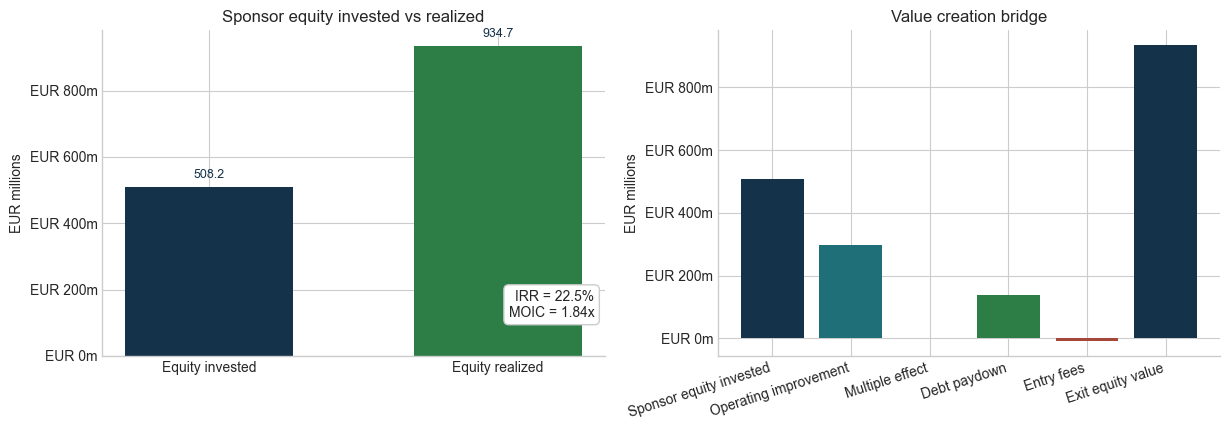

In [9]:
# Present the headline return outputs before decomposing them visually.
display(format_metric_table(returns_summary))
display(value_creation_bridge)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
# The left chart shows the sponsor outcome, while the right chart explains what created that outcome.
left_bars = axes[0].bar(
    ["Equity invested", "Equity realized"],
    [returns_lookup["Sponsor equity invested"], returns_lookup["Exit Equity Value"]],
    color=[COLORS["navy"], COLORS["green"]],
    width=0.58,
)
axes[0].set_title("Sponsor equity invested vs realized")
axes[0].set_ylabel("EUR millions")
axes[0].yaxis.set_major_formatter(FuncFormatter(eur_millions))
add_bar_labels(axes[0], left_bars, offset=18)
axes[0].text(
    0.98,
    0.12,
    f"IRR = {returns_lookup['IRR'] * 100:.1f}%\nMOIC = {returns_lookup['MOIC']:.2f}x",
    transform=axes[0].transAxes,
    ha="right",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc"},
)
style_axes(axes[0])

axes[1].bar(
    value_creation_bridge["Driver"],
    value_creation_bridge["Value"],
    color=[COLORS["navy"], COLORS["teal"], COLORS["sand"], COLORS["green"], COLORS["red"], COLORS["navy"]],
)
axes[1].set_title("Value creation bridge")
axes[1].set_ylabel("EUR millions")
axes[1].yaxis.set_major_formatter(FuncFormatter(eur_millions))
style_axes(axes[1])
plt.setp(axes[1].get_xticklabels(), rotation=18, ha="right")

plt.tight_layout()
plt.show()
        


## J. 8. What can break the deal?

No investment committee should approve an LBO on a single-point estimate. The real question is what happens when valuation or operating performance moves against the sponsor.

**Why this matters economically:** Sensitivity work shows whether the return case is robust or whether it collapses once a few assumptions become less favorable.

**Question in the room:** Which variables matter most, and how quickly does the sponsor return fall below an acceptable threshold if the deal is underwritten too aggressively?

**Where this sits in the process:** This is the risk-testing page that helps the IC distinguish a resilient deal from a fragile one.

The heatmaps make it easy to see where the return profile is supported by the underlying economics and where it becomes too dependent on favorable entry, exit, or growth assumptions.

> **IC takeaway:** A deal is only as good as its downside tolerance. Sensitivity analysis shows whether the base case is a sturdy centerline or just a narrow best-case path.

Once the committee understands the risks, the notebook can briefly show how the same engine could later be exposed in a simple analytical application.
        


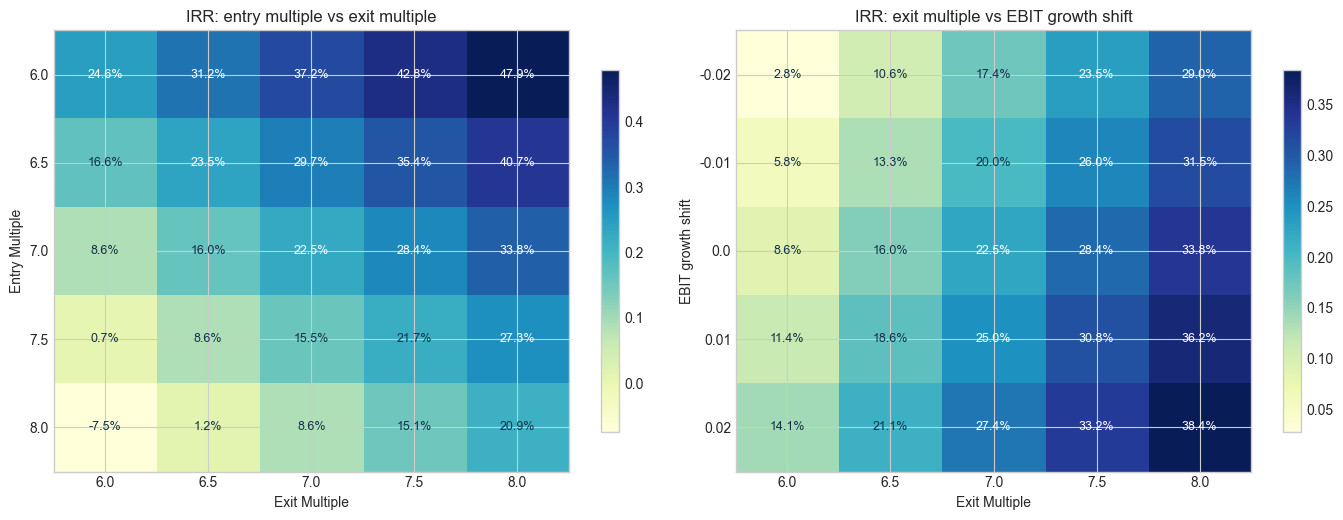

Exit Multiple,6.00,6.50,7.00,7.50,8.00
Entry Multiple,,,,,
6.00,24.60,31.20,37.20,42.80,47.90
6.50,16.60,23.50,29.70,35.40,40.70
7.00,8.60,16.00,22.50,28.40,33.80
7.50,0.70,8.60,15.50,21.70,27.30
8.00,-7.50,1.20,8.60,15.10,20.90


Exit Multiple,6.00,6.50,7.00,7.50,8.00
EBIT growth shift,,,,,
-0.02,1.09,1.35,1.62,1.88,2.15
-0.01,1.18,1.46,1.73,2.00,2.27
0.00,1.28,1.56,1.84,2.12,2.40
0.01,1.38,1.67,1.95,2.24,2.52
0.02,1.48,1.78,2.07,2.36,2.65


In [10]:
# Sensitivity analysis reinforces that one base case is never enough in transaction work.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
plot_heatmap(sensitivities["entry_exit_irr"], "IRR: entry multiple vs exit multiple", axes[0], percent_values=True)
plot_heatmap(sensitivities["exit_growth_irr"], "IRR: exit multiple vs EBIT growth shift", axes[1], percent_values=True)
plt.tight_layout()
plt.show()

display((sensitivities["entry_exit_irr"] * 100).round(1))
display((sensitivities["exit_growth_moic"]).round(2))
        


## K. 9. How could this model later be exposed through a simple analytical application?

Once the analytical engine is stable, the same model can be packaged into a lightweight decision-support tool.

**Why this matters economically:** The finance does not change, but the delivery format can. A reusable interface makes it easier to test scenarios without rebuilding the model each time.

**Question in the room:** How could the team share the same LBO logic in a faster analytical format without rewriting the calculations?

**Where this sits in the process:** This is a brief bridge from notebook work to a practical application layer, not a change to the underlying underwriting approach.

> **IC takeaway:** Productization should increase access to the analysis, not alter the analysis itself. The Streamlit app reuses the same model rather than creating a new one.
        


In [11]:
# Point students to the productization layer without duplicating the app inside the notebook.
streamlit_app_path = PROJECT_ROOT / "app" / "streamlit_lbo_demo.py"
print(f"Streamlit app: {streamlit_app_path}")
print("Run locally with: streamlit run app/streamlit_lbo_demo.py")
        


Streamlit app: C:\Users\julio\Documents\DemoCode\FinEngineering_AlgoTrading\app\streamlit_lbo_demo.py
Run locally with: streamlit run app/streamlit_lbo_demo.py


## L. Optional reporting layer

A completed model still needs a short written recommendation. The optional Gemini layer is a reporting aid that turns selected outputs into draft commentary.

**Why this matters economically:** It does not change the underwriting. It only helps the team summarize what the model already says.

**Question in the room:** Can the analyst produce a first-pass investment note without manually rewriting the same conclusions every time?

**Where this sits in the process:** This is a communication layer after the model is finished, not part of the valuation or debt mechanics themselves.

> **IC takeaway:** The AI is a drafting assistant, not a source of deal economics. If no API key is configured, the notebook skips this step without affecting the model.
        


In [12]:
# The AI layer reads the completed model outputs; it does not create the valuation itself.
commentary = generate_investment_commentary(results)

if commentary["success"]:
    display(Markdown(commentary["message"]))
else:
    print(commentary["message"])
        


**1. Executive summary**
*   This 3-year LBO delivered a 22.52% IRR and 1.84x MOIC.
*   Entry EV was 1685.6M at 7.0x historical EBITDA; sponsor equity invested 508.2M.

**2. Value creation drivers**
*   EBITDA grew 17.62% from 240.8M to 283.2M, driving exit equity value.
*   Deleveraging reduced net debt by 137.9M, representing 11.63% of total debt repaid.

**3. Key risks**
*   Exit multiple of 7.0x matched entry, indicating no multiple expansion contributed to returns.
*   Reliance on sustained EBITDA growth for value creation, absent multiple uplift.

**4. Overall assessment**
*   Strong returns achieved via operational improvement and free cash flow generation.
*   Exit net debt of 1047.9M resulted in a 3.70x total debt to EBITDA leverage.

## M. Investment committee wrap-up

The committee can now answer the original Monday morning question with structure rather than intuition.

- **What are we underwriting?** A business with a defined operating base, a clear financing package, and explicit exit assumptions.
- **What matters most?** Operating performance, cash conversion, and deleveraging because those are the levers that create sponsor equity value without relying on multiple expansion.
- **What can break the deal?** Overpaying at entry, missing the operating plan, or exiting into a weaker valuation environment.

In investment-committee terms, the lesson is simple: an LBO should be approved only when the return case is supported by realistic operations and a credible debt paydown path. The broader pedagogical point is equally important. This is not just a capital structure exercise; it is a disciplined way of linking underwriting assumptions, financing mechanics, lender protection, and sponsor returns into one coherent recommendation.
        
